In [1]:
# ── CELL 1: Imports and Load Trained Model ───────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

PROJECT_DIR = os.path.expanduser("~/GeoAID_Project")
DATA_DIR    = os.path.join(PROJECT_DIR, "data")
OUTPUTS_DIR = os.path.join(PROJECT_DIR, "outputs")
MODELS_DIR  = os.path.join(PROJECT_DIR, "models")
FIGURES_DIR = os.path.join(OUTPUTS_DIR, "figures")

print(f"SHAP version: {shap.__version__}")

# Load the selected Random Forest model
rf_model = joblib.load(os.path.join(MODELS_DIR, 'random_forest.pkl'))
print("✓ Random Forest model loaded")

# Load feature matrix
df = pd.read_csv(os.path.join(DATA_DIR, 'feature_matrix.csv'))

# Reconstruct the 14-feature set (distance_to_river removed in NB07)
non_features = ['longitude', 'latitude', 'flood_label', 'distance_to_river']
feature_cols = [c for c in df.columns if c not in non_features]

print(f"✓ Feature matrix loaded: {df.shape}")
print(f"  Features ({len(feature_cols)}): {feature_cols}")

X = df[feature_cols].copy()
y = df['flood_label'].copy()

SHAP version: 0.49.1
✓ Random Forest model loaded
✓ Feature matrix loaded: (8839, 18)
  Features (14): ['elevation', 'slope', 'aspect', 'flow_accumulation', 'twi', 'curvature', 'mean_annual_rainfall', 'mean_rainy_days', 'extreme_rain_freq', 'lulc', 'ndvi', 'soil_permeability', 'distance_to_drainage', 'gpm_antecedent_rainfall']


In [2]:
# ── CELL 2: Recreate Train-Test Split ────────────────────────────────────────
# Use the SAME split as NB07 (seed=42) so SHAP is computed on the exact
# test set the model was evaluated on. Consistency across notebooks matters.

from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.30,
    random_state = RANDOM_SEED,
    stratify     = y
)

print("Train-test split recreated (matches NB07):")
print(f"  Training: {len(X_train):,} samples")
print(f"  Test    : {len(X_test):,} samples")
print()

# Verify the model predicts correctly on this split
from sklearn.metrics import roc_auc_score
y_proba = rf_model.predict_proba(X_test)[:, 1]
auc_check = roc_auc_score(y_test, y_proba)
print(f"  ROC-AUC verification: {auc_check:.4f}")
print(f"  Expected (from NB07): 0.7979")
if abs(auc_check - 0.7979) < 0.001:
    print("  ✓ Split matches NB07 exactly — SHAP will be consistent")
else:
    print("  ⚠ Slight mismatch — check feature order")

Train-test split recreated (matches NB07):
  Training: 6,187 samples
  Test    : 2,652 samples

  ROC-AUC verification: 0.7979
  Expected (from NB07): 0.7979
  ✓ Split matches NB07 exactly — SHAP will be consistent


In [3]:
# ── CELL 3: Compute SHAP Values with TreeExplainer ───────────────────────────
# TreeExplainer computes exact SHAP values for tree ensembles in
# polynomial time. For Random Forest, it accounts for every tree's
# contribution to each prediction.
#
# We compute SHAP on the test set. For a binary classifier, TreeExplainer
# returns SHAP values for both classes; we focus on the flood class (1).
#
# Note: for 2,652 test samples × 14 features this takes 1-3 minutes.

print("Computing SHAP values with TreeExplainer...")
print("(This may take 1-3 minutes)")
print()

explainer = shap.TreeExplainer(rf_model)
shap_values_raw = explainer.shap_values(X_test)

# Handle SHAP output format — varies by version
# For binary RF, shap_values may be a list [class0, class1] or a 3D array
if isinstance(shap_values_raw, list):
    # Older format: list of arrays per class
    shap_values = shap_values_raw[1]  # flood class
    expected_value = explainer.expected_value[1]
    print("SHAP format: list (per-class)")
elif len(shap_values_raw.shape) == 3:
    # Newer format: (n_samples, n_features, n_classes)
    shap_values = shap_values_raw[:, :, 1]  # flood class
    expected_value = explainer.expected_value[1]
    print("SHAP format: 3D array")
else:
    # Single array
    shap_values = shap_values_raw
    expected_value = explainer.expected_value
    print("SHAP format: 2D array")

print(f"✓ SHAP values computed")
print(f"  Shape: {shap_values.shape}")
print(f"  Expected value (base rate): {expected_value:.4f}")
print(f"  Samples explained: {len(X_test):,}")

Computing SHAP values with TreeExplainer...
(This may take 1-3 minutes)

SHAP format: 3D array
✓ SHAP values computed
  Shape: (2652, 14)
  Expected value (base rate): 0.5007
  Samples explained: 2,652


  GLOBAL SHAP FEATURE IMPORTANCE

  ndvi                     0.0737 ████████████████████████████████████████
  elevation                0.0361 ███████████████████
  lulc                     0.0259 ██████████████
  distance_to_drainage     0.0248 █████████████
  soil_permeability        0.0233 ████████████
  aspect                   0.0168 █████████
  flow_accumulation        0.0168 █████████
  curvature                0.0150 ████████
  twi                      0.0149 ████████
  slope                    0.0132 ███████
  mean_rainy_days          0.0100 █████
  extreme_rain_freq        0.0083 ████
  mean_annual_rainfall     0.0075 ████
  gpm_antecedent_rainfall  0.0057 ███


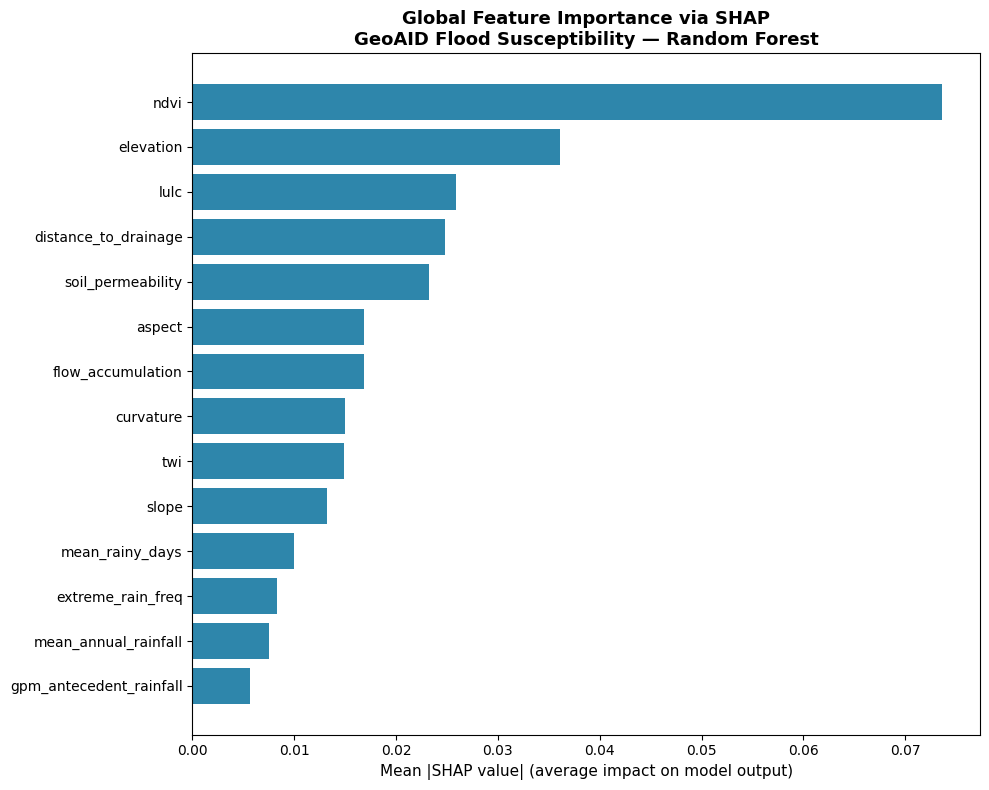


✓ SHAP importance bar chart saved


In [4]:
# ── CELL 4: Global SHAP Feature Importance ───────────────────────────────────
# Mean absolute SHAP value per feature = global importance.
# Unlike Gini importance, SHAP importance accounts for feature
# interactions and is not biased toward high-cardinality features.

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    'Feature'        : feature_cols,
    'Mean_Abs_SHAP'  : mean_abs_shap
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

print("=" * 55)
print("  GLOBAL SHAP FEATURE IMPORTANCE")
print("=" * 55)
print()
for _, row in shap_importance.iterrows():
    bar = '█' * int(row['Mean_Abs_SHAP'] / shap_importance['Mean_Abs_SHAP'].max() * 40)
    print(f"  {row['Feature']:24} {row['Mean_Abs_SHAP']:.4f} {bar}")

# Bar plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(shap_importance['Feature'][::-1],
        shap_importance['Mean_Abs_SHAP'][::-1],
        color='#2E86AB')
ax.set_xlabel('Mean |SHAP value| (average impact on model output)', fontsize=11)
ax.set_title('Global Feature Importance via SHAP\n'
             'GeoAID Flood Susceptibility — Random Forest',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'shap_importance_bar.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ SHAP importance bar chart saved")

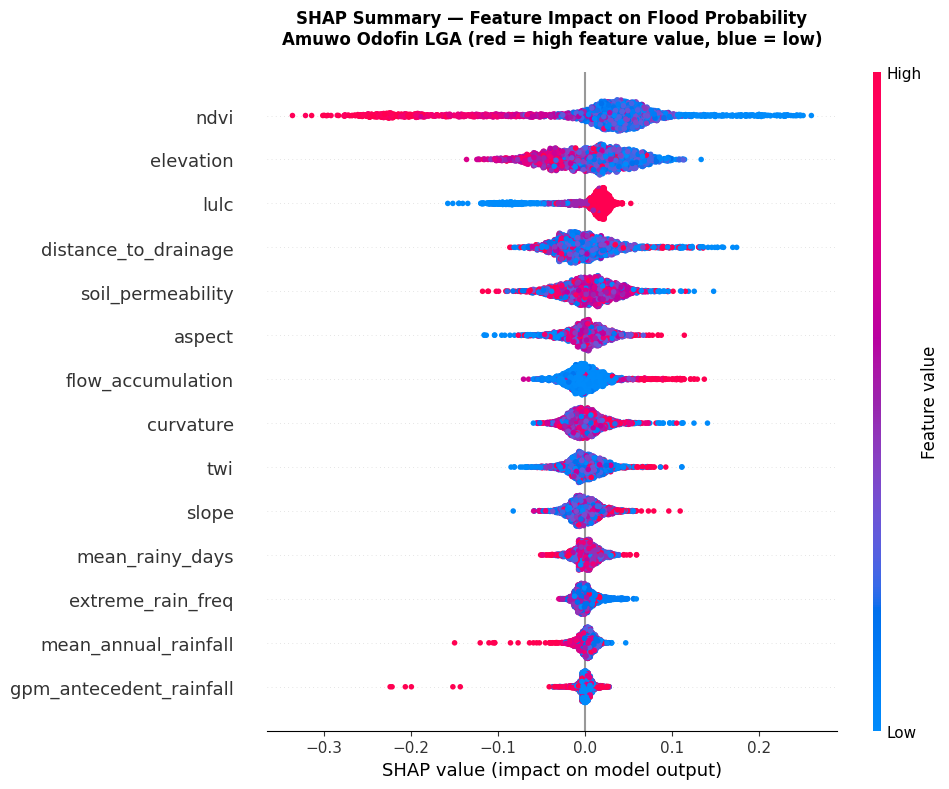

✓ SHAP beeswarm summary plot saved

Interpretation guide for writeup:
  - Features ordered top-to-bottom by importance
  - Points to the RIGHT increase flood probability
  - Points to the LEFT decrease flood probability
  - Red = high feature value, Blue = low feature value


In [5]:
# ── CELL 5: SHAP Beeswarm Summary Plot ───────────────────────────────────────
# The beeswarm plot is the single most informative SHAP visualisation.
# Each point is one sample. Position on x-axis = SHAP value (impact on
# prediction). Colour = feature value (red high, blue low).
# This reveals BOTH importance AND the direction of each feature's effect.
#
# Reading it: if high values of a feature (red) cluster on the positive
# SHAP side, that feature increases flood probability when high.

fig = plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names = feature_cols,
    show          = False,
    plot_size     = None
)
plt.title('SHAP Summary — Feature Impact on Flood Probability\n'
          'Amuwo Odofin LGA (red = high feature value, blue = low)',
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'shap_beeswarm.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ SHAP beeswarm summary plot saved")
print()
print("Interpretation guide for writeup:")
print("  - Features ordered top-to-bottom by importance")
print("  - Points to the RIGHT increase flood probability")
print("  - Points to the LEFT decrease flood probability")
print("  - Red = high feature value, Blue = low feature value")

Generating dependence plots for top 4 features:
  ['ndvi', 'elevation', 'lulc', 'distance_to_drainage']



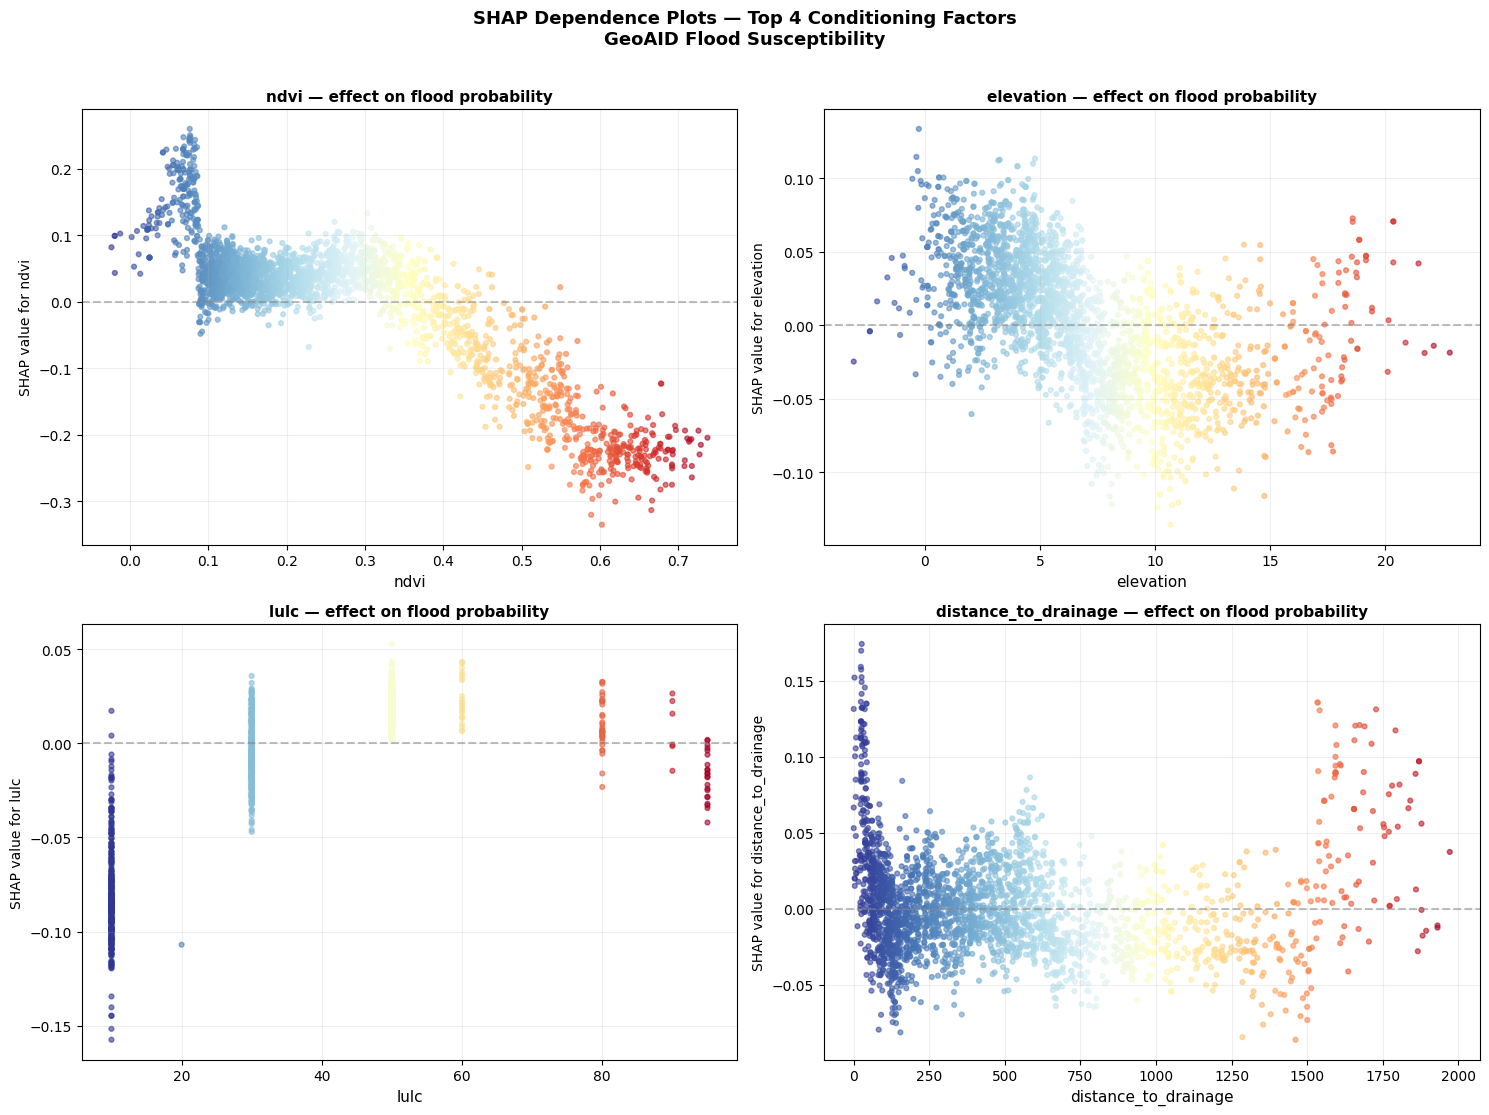

✓ SHAP dependence plots saved


In [6]:
# ── CELL 6: SHAP Dependence Plots ────────────────────────────────────────────
# Dependence plots show how a single feature's SHAP value changes across
# its value range — revealing non-linear relationships and thresholds.
# We plot the top 4 features by SHAP importance.

top_features = shap_importance['Feature'].head(4).tolist()
print(f"Generating dependence plots for top 4 features:")
print(f"  {top_features}")
print()

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    feat_idx = feature_cols.index(feat)
    axes[i].scatter(
        X_test[feat],
        shap_values[:, feat_idx],
        c=X_test[feat], cmap='RdYlBu_r', s=12, alpha=0.6
    )
    axes[i].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[i].set_xlabel(feat, fontsize=11)
    axes[i].set_ylabel(f'SHAP value for {feat}', fontsize=10)
    axes[i].set_title(f'{feat} — effect on flood probability',
                      fontsize=11, fontweight='bold')
    axes[i].grid(alpha=0.2)

plt.suptitle('SHAP Dependence Plots — Top 4 Conditioning Factors\n'
             'GeoAID Flood Susceptibility',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'shap_dependence_plots.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ SHAP dependence plots saved")

  LOCAL EXPLANATION — HIGHEST RISK LOCATION

  Predicted flood probability: 1.0000
  Actual label: Flood

  Feature contributions (SHAP values):
  Base value (expected): 0.5007

  ndvi                     =     0.09 | SHAP +0.1442 ↑ increases
  distance_to_drainage     =    26.02 | SHAP +0.1414 ↑ increases
  elevation                =     2.24 | SHAP +0.0662 ↑ increases
  mean_rainy_days          =   122.20 | SHAP +0.0277 ↑ increases
  aspect                   =   146.80 | SHAP +0.0242 ↑ increases
  lulc                     =    50.00 | SHAP +0.0187 ↑ increases
  soil_permeability        =    24.50 | SHAP +0.0162 ↑ increases
  slope                    =     3.30 | SHAP +0.0145 ↑ increases
  extreme_rain_freq        =     2.30 | SHAP +0.0136 ↑ increases
  mean_annual_rainfall     =  1748.69 | SHAP +0.0099 ↑ increases
  twi                      =     4.36 | SHAP +0.0094 ↑ increases
  curvature                =    -0.13 | SHAP +0.0063 ↑ increases
  flow_accumulation        =     8.25 | SH

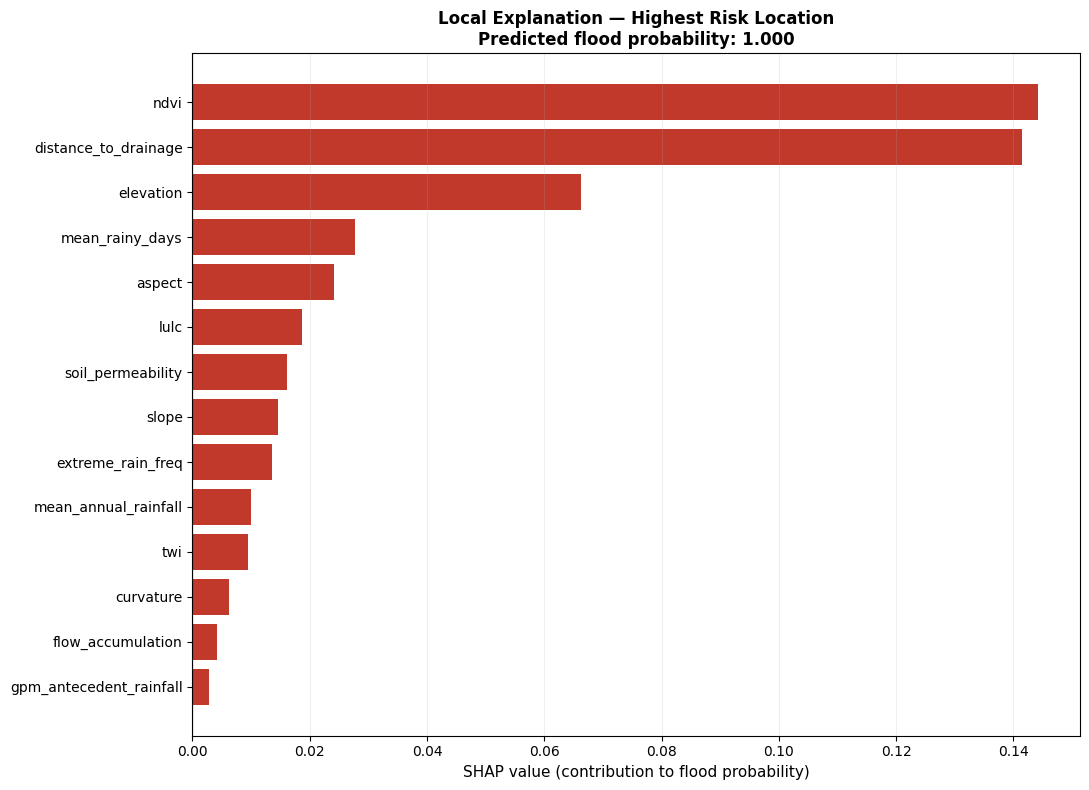


✓ Local explanation saved


In [7]:
# ── CELL 7: Local SHAP Explanation — Individual Predictions ──────────────────
# Local explanations show WHY a specific location received its prediction.
# This is the Layer 3 disaster intelligence capability — explaining a
# single high-risk zone to an emergency responder.
#
# We select the highest-probability flood prediction in the test set
# and decompose it into feature contributions.

# Find the highest-confidence flood prediction
test_proba = rf_model.predict_proba(X_test)[:, 1]
highest_idx = np.argmax(test_proba)

print("=" * 55)
print("  LOCAL EXPLANATION — HIGHEST RISK LOCATION")
print("=" * 55)
print()
print(f"  Predicted flood probability: {test_proba[highest_idx]:.4f}")
print(f"  Actual label: {'Flood' if y_test.iloc[highest_idx]==1 else 'Non-flood'}")
print()
print("  Feature contributions (SHAP values):")
print(f"  Base value (expected): {expected_value:.4f}")
print()

local_shap = shap_values[highest_idx]
local_contribution = pd.DataFrame({
    'Feature'    : feature_cols,
    'Value'      : X_test.iloc[highest_idx].values,
    'SHAP'       : local_shap
}).sort_values('SHAP', key=abs, ascending=False).reset_index(drop=True)

for _, row in local_contribution.iterrows():
    direction = '↑ increases' if row['SHAP'] > 0 else '↓ decreases'
    print(f"  {row['Feature']:24} = {row['Value']:8.2f} | "
          f"SHAP {row['SHAP']:+.4f} {direction}")

# Waterfall-style visualisation
fig, ax = plt.subplots(figsize=(11, 8))
sorted_contrib = local_contribution.sort_values('SHAP')
colors = ['#C0392B' if v > 0 else '#2E86AB' for v in sorted_contrib['SHAP']]
ax.barh(sorted_contrib['Feature'], sorted_contrib['SHAP'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP value (contribution to flood probability)', fontsize=11)
ax.set_title(f'Local Explanation — Highest Risk Location\n'
             f'Predicted flood probability: {test_proba[highest_idx]:.3f}',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'shap_local_highrisk.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Local explanation saved")

In [8]:
# ── CELL 8: Save SHAP Results and Notebook Summary ───────────────────────────

# Save SHAP importance table
shap_importance.to_csv(os.path.join(OUTPUTS_DIR, 'shap_importance.csv'),
                        index=False)

# Save SHAP values array for dashboard use
np.save(os.path.join(MODELS_DIR, 'shap_values.npy'), shap_values)
joblib.dump(explainer, os.path.join(MODELS_DIR, 'shap_explainer.pkl'))

print("=" * 60)
print("  NOTEBOOK 08 — SHAP EXPLAINABILITY: COMPLETE")
print("=" * 60)
print()
print("  Global importance ranking (SHAP):")
for i, row in shap_importance.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']:24} {row['Mean_Abs_SHAP']:.4f}")
print()
print("  Figures generated:")
print("  ├── shap_importance_bar.png")
print("  ├── shap_beeswarm.png")
print("  ├── shap_dependence_plots.png")
print("  └── shap_local_highrisk.png")
print()
print("  Saved artefacts:")
print("  ├── outputs/shap_importance.csv")
print("  ├── models/shap_values.npy")
print("  └── models/shap_explainer.pkl")
print()
print("  Next: NB09 — Infrastructure risk assessment (OSM + WorldPop)")
print("=" * 60)

  NOTEBOOK 08 — SHAP EXPLAINABILITY: COMPLETE

  Global importance ranking (SHAP):
  1. ndvi                     0.0737
  2. elevation                0.0361
  3. lulc                     0.0259
  4. distance_to_drainage     0.0248
  5. soil_permeability        0.0233

  Figures generated:
  ├── shap_importance_bar.png
  ├── shap_beeswarm.png
  ├── shap_dependence_plots.png
  └── shap_local_highrisk.png

  Saved artefacts:
  ├── outputs/shap_importance.csv
  ├── models/shap_values.npy
  └── models/shap_explainer.pkl

  Next: NB09 — Infrastructure risk assessment (OSM + WorldPop)
